[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://www.kaggle.com/code/maryrobynbernabe/coral-project-6-vgg16-training)

# Set dataset path

In [1]:

# Please replace the brackets below with the drive location of your folders which included subfolders for images
# Sample path: /content/drive/My Drive/ImageClassification
TRAINING_PATH = '/kaggle/input/notebooks/maryrobynbernabe/coral-project-1-dataset-splitting/train'
VALIDATION_PATH = '/kaggle/input/notebooks/maryrobynbernabe/coral-project-1-dataset-splitting/val'

# Function to add extra layers on the base model

In [2]:
def create_model(base_model, num_classes):
    import tensorflow as tf
    # Grab the last layer and add a few extra layers to it
    x=base_model.output
    x=GlobalAveragePooling2D()(x)
    # Dense layer 1
    x=tf.keras.layers.Dense(100,activation='relu', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=True)(x)

    # Final layer with softmax activation
    preds=tf.keras.layers.Dense(num_classes,activation='softmax', kernel_initializer=tf.keras.initializers.VarianceScaling(), use_bias=False)(x)

    # Create the final model
    model=Model(inputs=base_model.input,outputs=preds)
    return model


# Function to select optimizer

In [3]:
def get_optimizer(optimizer_name, learning_rate):
    # Import keras optimizers
    from tensorflow.keras.optimizers import Adam, Adadelta, Adagrad, Adamax, Ftrl, Nadam, RMSprop, SGD
    print('Selected Optimizer', optimizer_name)
    switcher = {
        'Adadelta': Adadelta(learning_rate=learning_rate),
        'Adagrad': Adagrad(learning_rate=learning_rate),
        'Adam': Adam(learning_rate=learning_rate),
        'Adamax': Adamax(learning_rate=learning_rate),
        'FTRL': Ftrl(learning_rate=learning_rate),
        'NAdam': Nadam(learning_rate=learning_rate),
        'RMSprop': RMSprop(learning_rate=learning_rate),
        'Gradient Descent': SGD(learning_rate=learning_rate)
    }
    # If optimizer_name is empty, Adam will be return as default optimizer
    return switcher.get(optimizer_name, Adam(learning_rate=learning_rate))


# Data loading and training

In [4]:

# Import packages needed to create a image classification model
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from keras.applications.resnet import preprocess_input
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,GlobalAveragePooling2D
from keras.models import Model
from tensorflow.keras import regularizers

from tensorflow.keras.preprocessing import image_dataset_from_directory
from keras.callbacks import EarlyStopping
from tensorflow import keras

# Initialize hyper params
epochs = 5 #<-- increase for higher accuracy
base_learning_rate = 0.001 #decrease for different results; use excel sheet to note down results from each change to learning rate and epochs
optimizer = 'Adam'
BATCH_SIZE = 32

IMG_SIZE = (224, 224)

# Create the data generation pipeline for training and validation
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(TRAINING_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )
validation_generator = validation_datagen.flow_from_directory(VALIDATION_PATH,
                                                target_size=IMG_SIZE,
                                                color_mode='rgb',
                                                batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                shuffle=True,
                                                )

print(validation_generator.class_indices.keys())
# Download the model, valid alpha values [0.25,0.35,0.5,0.75,1]
base_model = tf.keras.applications.VGG16(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
for layer in base_model.layers:
    layer.trainable=False

# Specify the number of classes
num_classes = 2

# Create the base model
model = create_model(base_model,num_classes)

print(len(base_model.layers))

model.compile(optimizer = get_optimizer(optimizer_name=optimizer,learning_rate=base_learning_rate),loss='CategoricalCrossentropy',metrics=['accuracy'])
# Adam optimizer
# loss function will be categorical cross entropy
# evaluation metric will be accuracy

early_stopping_monitor = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=30,
    verbose=0,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

step_size_train = train_generator.n//train_generator.batch_size
history_fine = model.fit(train_generator,
                        epochs=epochs,
                        validation_data = validation_generator,
                        verbose=1)
model.save(f"/kaggle/working/VGG16_epochs_{epochs}_learning_rate_{base_learning_rate}.h5")

Found 704 images belonging to 2 classes.
Found 86 images belonging to 2 classes.
dict_keys(['bleached_corals', 'healthy_corals'])
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
19
Selected Optimizer Adam
Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 642ms/step - accuracy: 0.6562 - loss: 1.0856 - val_accuracy: 0.7674 - val_loss: 0.4926
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.7500 - loss: 0.5423 - val_accuracy: 0.7674 - val_loss: 0.5715
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 182ms/step - accuracy: 0.8310 - loss: 0.3455 - val_accuracy: 0.7674 - val_loss: 0.4304
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.8935 - loss: 0.2696 - val_accuracy: 0.8140 - val_loss: 0.3941
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9119 - loss: 0.2301 - val_accuracy: 0.8372 - val_loss: 0.3834


# Function to visulaize results

In [5]:
print(history_fine.history)

{'accuracy': [0.65625, 0.75, 0.8309659361839294, 0.8934659361839294, 0.9119318127632141], 'loss': [1.0855908393859863, 0.5422993898391724, 0.3455183207988739, 0.2695556879043579, 0.23007644712924957], 'val_accuracy': [0.7674418687820435, 0.7674418687820435, 0.7674418687820435, 0.8139534592628479, 0.8372092843055725], 'val_loss': [0.4925832152366638, 0.5715492367744446, 0.4303802251815796, 0.3940882980823517, 0.3834061622619629]}


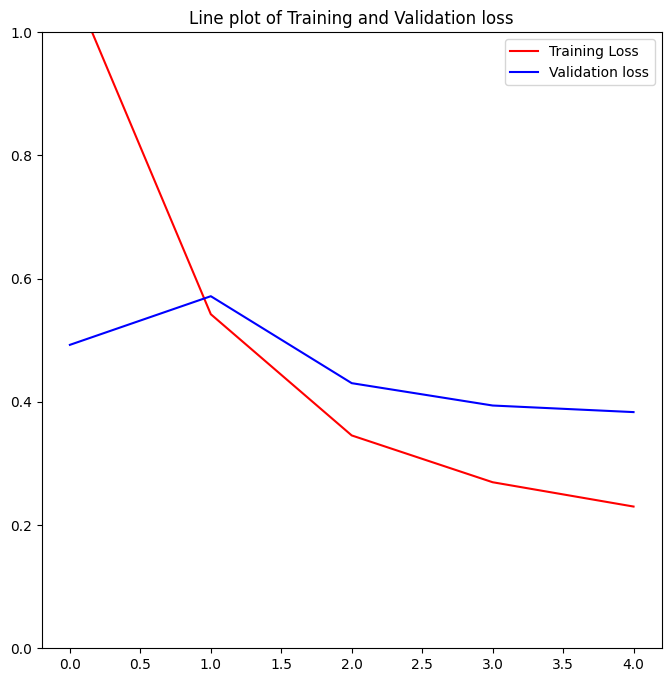

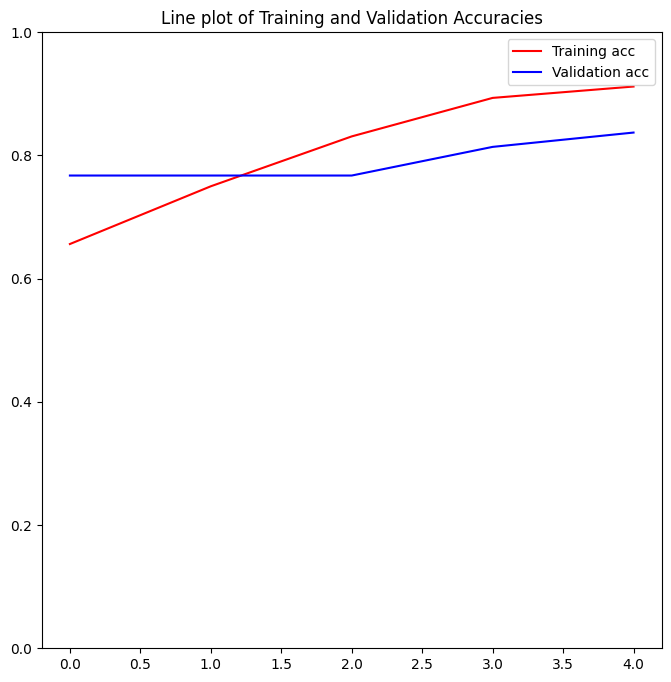

In [6]:
def visualization():
    import pandas as pd
    df = pd.DataFrame(history_fine.history)
    #loss plots
    plt.figure(figsize=(8,8))
    plt.plot(df['loss'], color='red', label = "Training_loss")
    plt.plot(df['val_loss'], color='blue')
    plt.legend(['Training Loss','Validation loss'],loc = 'best' )
    plt.title('Line plot of Training and Validation loss')
    plt.ylim(0,1)
    plt.show()
    

    #accuracy plots
    plt.figure(figsize=(8,8))
    plt.plot(df['accuracy'], color='red')
    plt.plot(df['val_accuracy'], color='blue')
    plt.legend(['Training acc','Validation acc'],loc = 'best' )
    plt.title('Line plot of Training and Validation Accuracies')
    plt.ylim(0,1)
    plt.show()

visualization()

# Check for the best accuracy

In [7]:

# Import numpy for calculating best model accuracy
import numpy as np
# Populating matrics -> accuracy & loss
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']

loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

print('Training Accuracy: ', acc)
print('Validation Accuracy: ', val_acc)
print('Training Loss: ', loss)
print('Validation Loss: ', val_loss)
best_model_accuracy = history_fine.history['val_accuracy'][np.argmin(history_fine.history['val_loss'])]
print('best model accuracy: ', best_model_accuracy)


Training Accuracy:  [0.65625, 0.75, 0.8309659361839294, 0.8934659361839294, 0.9119318127632141]
Validation Accuracy:  [0.7674418687820435, 0.7674418687820435, 0.7674418687820435, 0.8139534592628479, 0.8372092843055725]
Training Loss:  [1.0855908393859863, 0.5422993898391724, 0.3455183207988739, 0.2695556879043579, 0.23007644712924957]
Validation Loss:  [0.4925832152366638, 0.5715492367744446, 0.4303802251815796, 0.3940882980823517, 0.3834061622619629]
best model accuracy:  0.8372092843055725


# Function to separate labels from dataset

In [8]:
def seperate_labels(generator):
    x_validation = []
    y_validation = []
    num_seen = 0

    for x, labels in generator:
        x_validation.append(x)
        y_validation.append([argmax(label) for label in labels])
        num_seen += len(x)
        if num_seen == generator.n: break

    x_validation = np.concatenate(x_validation)
    y_validation = np.concatenate(y_validation)
    return x_validation, y_validation


# Plot confusion matrix

In [9]:

# Calculate and display the confusion matrix
import matplotlib.pyplot as plt
from numpy.core.fromnumeric import argmax
from sklearn.metrics import ConfusionMatrixDisplay

x_validation, y_validation = seperate_labels(validation_generator)
y_pred = model.predict(x_validation, batch_size=BATCH_SIZE)
predictions = np.apply_along_axis(argmax, 1, y_pred)
display_labels = validation_generator.class_indices.keys()

# ConfusionMatrixDisplay.from_predictions(y_validation, predictions, display_labels=display_labels, cmap="binary")
# plt.show()


/tmp/ipykernel_30/1308144587.py:3: DeprecationWarning: numpy.core.fromnumeric is deprecated and has been renamed to numpy._core.fromnumeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.fromnumeric.argmax.
  from numpy.core.fromnumeric import argmax


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step


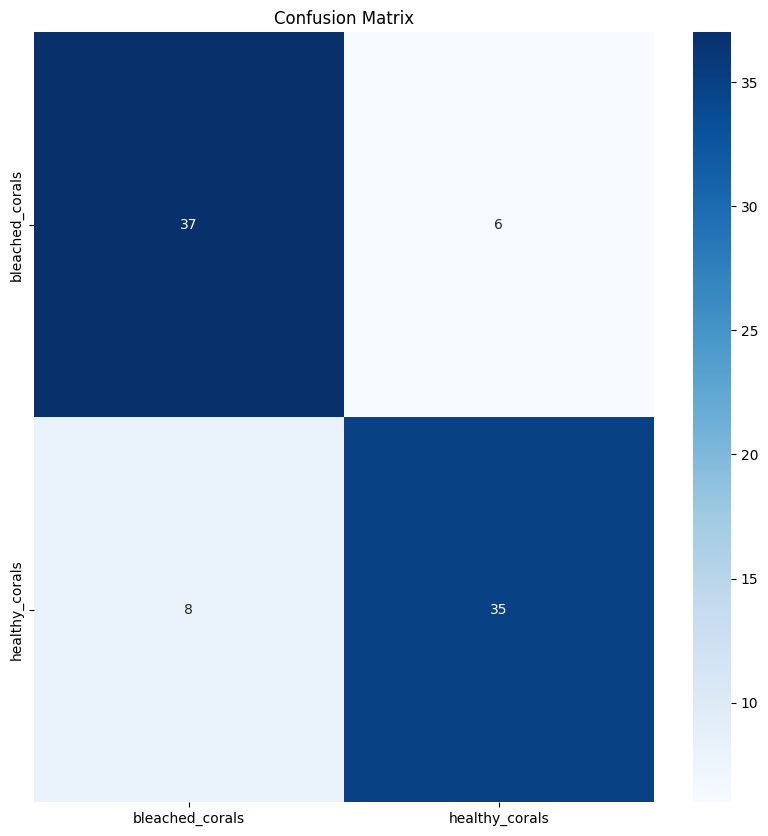

In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
plt.figure(figsize = (10,10))
sns.heatmap(confusion_matrix(y_validation, predictions), annot = True, fmt = 'g', cmap = "Blues",xticklabels=display_labels, yticklabels=display_labels)
plt.title("Confusion Matrix")
plt.show()

# Print classification report

In [11]:
print(classification_report(y_validation, predictions))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        43
           1       0.85      0.81      0.83        43

    accuracy                           0.84        86
   macro avg       0.84      0.84      0.84        86
weighted avg       0.84      0.84      0.84        86

